# Targeted CW search of NANOGrav 15-year dataset

This notebook reproduces (some) results from the [NANOGrav 15-year targeted search analysis](https://arxiv.org/pdf/2508.16534).

# **STILL IN TESTING!**

The targeted CW deterministic model induces complex posterior geometry which is *very* non-Gaussian (see posteriors in the paper linked above). NumPyro's NUTS sampler struggles to resolve such multi-modal non-Gaussian posteriors. While this notebook technically implements a targeted search model in Prometheus, we need to investigate methods to improve the sampling beyond what NUTS is capable.

In [1]:
# to load/save objects
import pickle
import h5py

# for plotting
import numpy as np
import matplotlib.pyplot as plt
import corner

# for sampling
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro

# prometheus objects
from prometheus.spectral_models import IndependentSpectralModel, CommonSpectralModel
from prometheus import spectra
from prometheus.deterministic_models import DeterministicModel
from prometheus import deterministic
from prometheus.pta_model import PTAModel
from prometheus import posterior
from prometheus import utilities as utils

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [2]:
# check that we are running on a GPU
# this should print something like "CudaDevice(id=...)"
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


## Load Data

Prometheus stores PTA data in a custom `prometheus.data.Data` object. This object may be constructed from a list of `enterprise.Pulsar.PintPulsar` (or `FeatherPulsar`) objects and a white noise dictionary.

The `Data` object needs only be constructed once per dataset, after which it can be stored and used repeatedly under different models. The only exception is when we wish to change the number of frequency bins used in the pulsar noise or deterministic signal model.

In [3]:
# load previously created data object (see gwb_pe.ipynb)
with open('../../data/NG15/data.pkl', 'rb') as fp:
    NG15_data = pickle.load(fp)

## Construct Spectral Models

Build the pulsar and GWB spectral models used in the stochastic part of the analysis. To compare our results with chains from the 15-year targeted search, we'll sample under the CURN GWB model.

In [4]:
# we'll model the pulsar noise with a power law
# the IndependentSpectralModel automatically applies this model to
# every pulsar in the array independently
psr_model = IndependentSpectralModel(name='irn_pl',
                                     get_phi_diag_func=spectra.power_law,
                                     parameter_bounds=[[-20., -10.], # log_amp bounds
                                                       [0., 7.]],    # spectral index bounds
                                     data=NG15_data)

# model the GWB with a power law (no inter-pulsar correlations)
# also specify the number of frequency bins used in the GWB model
gwb_model = CommonSpectralModel(name='gwb_pl',
                                    get_phi_diag_func=spectra.power_law,
                                    parameter_bounds=[[-20., -10.], # log_amp bounds
                                                        [0., 7.]],    # spectral index bounds
                                    correlation_matrix='CURN', # try changing to 'HD'!
                                    data=NG15_data,
                                    nfreqs=14)

## Specify deterministic model

**Prometheus** supports the construction of arbitrary deterministic models, whose parameters will be jointly inferred with those of spectral models. To add a deterministic signal, we must build a `prometheus.deterministic_models.DeterministicModel` object. The most important attribute of this object is a `get_delays_func` which returns the timing delays induced by the deterministic signal (across puslars) given a set of deterministic model parameters. The `get_delays_func` for an evolving continuous wave from an individual circular binary (with pulsar terms) can be found in `deterministic.py`.

Users can construct a custom `get_delays_func` to make their own deterministic models. However, they should verify their model is stable in single precision and accurately represented in a Fourier basis (see the `tests` folder).

An evolving CW model is available in `deterministic.py`. To conduct a targeted search, we just need to fix some of the parameters of the pre-built CW delays function.

In [5]:
# fixed parameters of targeted search

#  J1536+0441  (Rohan)
cos_gwtheta_fixed = 0.08177857385
gwphi_fixed = 4.08670298796
log10_fgw_fixed = -7.681197805336018
dist_Mpc_fixed = 10**3.315126105863233

#  J0729+4008  (Gondor)
# cos_gwtheta_fixed = 0.645
# gwphi_fixed = 1.959
# log10_fgw_fixed = -7.842848784336018
# dist_Mpc_fixed = 10**2.529120665470566

The NANOGrav 15-year targeted search code uses a slightly modified CW model than the one implemented in `deterministic.py`. To check results we need to use the same model. Below we *copy* code from 15-year analysis [found here](https://zenodo.org/records/17289574) and only modify it so it is JAX compatible and batched over pulsars in the array.

In [6]:
def create_gw_antenna_pattern_new(pos, gwtheta, gwphi, gwpsi):
    """
    Function to create pulsar antenna pattern functions as defined
    in Ellis, Siemens, and Creighton (2012).
    :param theta: Polar angle of pulsar location.
    :param phi: Azimuthal angle of pulsar location.
    :param gwtheta: GW polar angle in radians
    :param gwphi: GW azimuthal angle in radians
    
    :return: (fplus, fcross, cosMu), where fplus and fcross
             are the plus and cross antenna pattern functions
             and cosMu is the cosine of the angle between the 
             pulsar and the GW source.
    """
    """
    JAE version:
        m = np.array([np.sin(gwphi), -np.cos(gwphi), 0.0])
        n = np.array([-np.cos(gwtheta)*np.cos(gwphi), 
                  -np.cos(gwtheta)*np.sin(gwphi),
                  np.sin(gwtheta)])
        omhat = np.array([-np.sin(gwtheta)*np.cos(gwphi), 
                      -np.sin(gwtheta)*np.sin(gwphi),
                      -np.cos(gwtheta)])
    """
    # use definition from SRT
    
    
    
    n = jnp.array([jnp.sin(gwtheta)*jnp.cos(gwphi),
                 jnp.sin(gwtheta)*jnp.sin(gwphi),
                 jnp.cos(gwtheta)])
    omhat = -n
    p = jnp.array([jnp.cos(gwpsi)*jnp.cos(gwtheta)*jnp.cos(gwphi)-
                  jnp.sin(gwpsi)*jnp.sin(gwphi),
                 jnp.cos(gwpsi)*jnp.cos(gwtheta)*jnp.sin(gwphi)+
                 jnp.sin(gwpsi)*jnp.cos(gwphi),
                 -jnp.cos(gwpsi)*jnp.sin(gwtheta)])
    #p = -n for psi = 0
    
    q = jnp.array([jnp.sin(gwpsi)*jnp.cos(gwtheta)*jnp.cos(gwphi)+
                  jnp.cos(gwpsi)*jnp.sin(gwphi),
                 jnp.sin(gwpsi)*jnp.cos(gwtheta)*jnp.sin(gwphi)-
                 jnp.cos(gwpsi)*jnp.cos(gwphi),
                 -jnp.sin(gwpsi)*jnp.sin(gwtheta)])
    #q = m for psi = 0

    u = pos #np.array([np.sin(theta)*np.cos(phi), 
                     #np.sin(theta)*np.sin(phi), 
                     #np.cos(theta)])

    fplus = 0.5 * (jnp.dot(u,p)**2 - jnp.dot(u, q)**2) / (1+jnp.dot(omhat, u))
    fcross = (jnp.dot(u, p)*jnp.dot(u, q)) / (1 + jnp.dot(omhat, u))
    cosMu = -jnp.dot(omhat, u)

    return fplus, fcross, cosMu

def cw_delay_new(toas, psr_pos, source_params, psr_phases, psr_dists):
    
    # unpack parameters
    log10_mc, log10_fgw, cos_inc, psi, log10_h, cos_gwtheta, gwphi, phase0 = source_params

    # convert units to time
    mc = 10**log10_mc * utils.Tsun
    fgw = 10**log10_fgw
    gwtheta = jnp.arccos(cos_gwtheta)
    inc = jnp.arccos(cos_inc)
    p_dist = psr_dists*utils.kpc/utils.c
    dist = 2 * mc**(5/3) * (jnp.pi*fgw)**(2/3) / 10**log10_h

    # get antenna pattern funcs and cosMu
    # write function to get pos from theta,phi
    fplus, fcross, cosMu = jax.vmap(lambda pos: create_gw_antenna_pattern_new(pos, gwtheta, gwphi, psi))(psr_pos)

    # get pulsar time
    
    #toas -= tref
    #safety! compounds can go wrong!
    toas_copy = toas-utils.tref
    # if p_dist > 0:
    tp = toas_copy-(p_dist*(1-cosMu))[:, None]
    # else:
    #     tp = toas

    # orbital frequency
    w0 = jnp.pi * fgw
    phase0 = phase0 / 2 # orbital phase
    #omegadot = 96/5 * mc**(5/3) * w0**(11/3)


    # calculate time dependent frequency at earth and pulsar
    omega = w0 * (1 - 256/5 * mc**(5/3) * w0**(8/3) * toas_copy)**(-3/8)
    omega_p = w0 * (1 - 256/5 * mc**(5/3) * w0**(8/3) * tp)**(-3/8)

    omega_p0 = (w0 * (1 + 256/5
                            * mc**(5/3) * w0**(8/3) *
                            p_dist*(1-cosMu))**(-3/8))[:, None]
    # calculate time dependent phase
    phase = phase0 + 1/32/mc**(5/3) * (w0**(-5/3) - omega**(-5/3))

    phase_p = (phase0 + psr_phases[:, None]
                    + 1/32*mc**(-5/3) * (omega_p0**(-5/3) -
                                        omega_p**(-5/3)))

    # define time dependent coefficients
    At = -0.5*jnp.sin(2*phase)*(3+jnp.cos(2*inc)) # equivalent to -np.sin(2*phase)*(1+np.cos(inc)**2)
    Bt = 2*jnp.cos(2*phase)*jnp.cos(inc)
    At_p = -0.5*jnp.sin(2*phase_p)*(3+jnp.cos(2*inc)) # equivalent to -np.sin(2*phase_p)*(1+np.cos(inc)**2)
    Bt_p = 2*jnp.cos(2*phase_p)*jnp.cos(inc)

    # now define time dependent amplitudes
    alpha = mc**(5./3.)/(dist*omega**(1./3.))
    alpha_p = mc**(5./3.)/(dist*omega_p**(1./3.))

    # define rplus and rcross
    '''
    rplus = alpha*(-At*np.cos(2*psi)+Bt*np.sin(2*psi))
    rcross = alpha*(At*np.sin(2*psi)+Bt*np.cos(2*psi))
    rplus_p = alpha_p*(-At_p*np.cos(2*psi)+Bt_p*np.sin(2*psi))
    rcross_p = alpha_p*(At_p*np.sin(2*psi)+Bt_p*np.cos(2*psi))
    '''

    
    rplus = alpha*(At)
    rcross = alpha*(-Bt) # TODO: figure out why a minus sign here?
    rplus_p = alpha_p*(At_p)
    rcross_p = alpha_p*(-Bt_p) # TODO: figure out why a minus sign here?
    

    # residuals
    res = fplus[:, None]*(rplus_p-rplus)+fcross[:, None]*(rcross_p-rcross)

    return res * utils.renorm

Now we can use the general CW model above, fix some parameters, and design a targeted search deterministic model.

In [7]:
# get CW delays under targeted search
def targeted_delay(toas, psr_pos, source_params, psr_phases, psr_dists):

    # unpack (sampled) parameters - the rest are fixed in targeted search
    log10_mc, cos_inc, psi, phase0 = source_params

    # amplitude determined from other parameters
    log10_h = (jnp.log10(2) + 5/3*log10_mc + 5/3*jnp.log10(utils.Tsun)
               + jnp.log10(jnp.pi) + 2/3*log10_fgw_fixed
               - jnp.log10(dist_Mpc_fixed) - jnp.log10(utils.Mpc)
               + jnp.log10(utils.c))
    
    # concatenate all CW parameters into array accepted by delay function
    all_cw_source_params = jnp.array([log10_mc, log10_fgw_fixed, cos_inc, psi,
                                      log10_h, cos_gwtheta_fixed, gwphi_fixed, phase0])

    # get delays induced by CW
    targeted_cw_delay = cw_delay_new(toas=toas,
                                    psr_pos=psr_pos,
                                    source_params=all_cw_source_params,
                                    psr_phases=psr_phases,
                                    psr_dists=psr_dists)
    return targeted_cw_delay

### Correct the pulsar distance priors

By default, **Prometheus** uses normal priors on pulsar distance parameters. Better priors are those of [Arzoumanian et al. 2023](https://arxiv.org/pdf/2301.03608) Eq. 20 & 21. We can modify the pulsar distance prior in the following function, then add it to the `DeterministicModel`.

In [10]:
# which pulsar distances are measured with parallax and DM
where_PX = jnp.where(NG15_data.psr_dist_method == 'PX')[0]
where_DM = jnp.where(NG15_data.psr_dist_method == 'DM')[0]

# measured pulsar distance and uncertainty
psr_dists_measured = jnp.array(NG15_data.psr_dists_measured)
psr_dists_std = jnp.array(NG15_data.psr_dists_std)

# the additional prior takes all determinstic model parameters as input
def psr_dists_lnprior(cw_source_params, psr_phases, psr_dists):

    # prior on pulsar distance when measured with parallax
    lnpriors_PX_dist = jax.vmap(lambda x, y, z : posterior.ln_p_PX(x, y, z),
                                in_axes=(0, 0, 0))(psr_dists, psr_dists_measured, psr_dists_std)
    lnprior_PX_summed = jnp.sum(lnpriors_PX_dist[where_PX])

    # prior on pulsar distance when measured with DM
    lnpriors_DM_dist = jax.vmap(lambda x, y, z : posterior.ln_p_DM(x, y, z),
                                in_axes=(0, 0, 0))(psr_dists, psr_dists_measured, psr_dists_std)
    lnprior_DM_summed = jnp.sum(lnpriors_DM_dist[where_DM])

    # Prometheus still samples pulsar distance using a normal prior,
    # so sneakily subtract that density here
    ln_normal_correction = 0.5 * jnp.sum((psr_dists - psr_dists_measured)**2 / psr_dists_std**2)

    # new "advanced" pulsar distance prior
    return lnprior_PX_summed + lnprior_DM_summed + ln_normal_correction

In [11]:
# the minimum/maximum values of the source parameters described above
# the pulsar distance and phase parameters are sampled automatically
cw_source_mins = np.array([7., -1., 0, 0.])
cw_source_maxs = np.array([10., 1., np.pi, 2. * np.pi])
cw_parameter_bounds = np.array([cw_source_mins, cw_source_maxs]).T

# now we can build the deterministic model 
targeted_cw_model = DeterministicModel(name='cw_evolve',
                                       data=NG15_data,
                                       get_delays_func=targeted_delay,
                                       parameter_bounds=cw_parameter_bounds,
                                       with_psr_params=True,
                                       additional_ln_factor=psr_dists_lnprior)

## Build a PTA model

In [12]:
pta_model = PTAModel(psr_model=psr_model,
                     gwb_model=gwb_model,
                     det_model=targeted_cw_model)
print(type(pta_model))

<class 'prometheus.pta_model.PTAModel'>


## Sample the posterior!

Sample as usual with HMC NUTS.

In [16]:
from numpyro.infer.initialization import init_to_value

In [ ]:
# build the NumPyro NUTS kernel
nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model)

# specify MCMC attributes
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000)

# seed to start sampling
# if you see step size < 1e-5, change this seed and try again!
seed = 342166

# run MCMC and get samples
mcmc.run(jr.PRNGKey(seed))
samples = mcmc.get_samples()

In [ ]:
# uncomment to examine sampling diagnostics
# (this is a long output because we sample 
# ALL the Fourier coefficients)

# mcmc.print_summary()

In [ ]:
# save samples to feather file
utils.save_chain(samples_dict=samples,
                 filepath='../chains/NG15_CURN_Rohan.feather')

# we can also load samples
# samples = utils.load_chain('../chains/NG15_CURN_Rohan.feather')

## Post-processing

Let's examine the samples and make some plots. We'll compare our samples to those of the [15-year targeted search paper](https://arxiv.org/pdf/2508.16534).

In [ ]:
# load samples from 15-year targeted search paper
with h5py.File('../chains/SDSS_J153636.22+044127.0_det.h5', 'r') as f:
# with h5py.File('../chains/SDSS_J072908.71+400836.6_det.h5', 'r') as f:
    targeted_search_samples = f['chain'][:, -12:-5]
    # GWB samples
    targeted_gwb_samples = targeted_search_samples[:, np.r_[1, 2]]
    # CW samples re-ordered to our convention
    ordering = np.array([1, 0, -2, 2, -1])
    targeted_cw_samples = (targeted_search_samples[:, np.r_[0, 3:7]])[:, ordering]

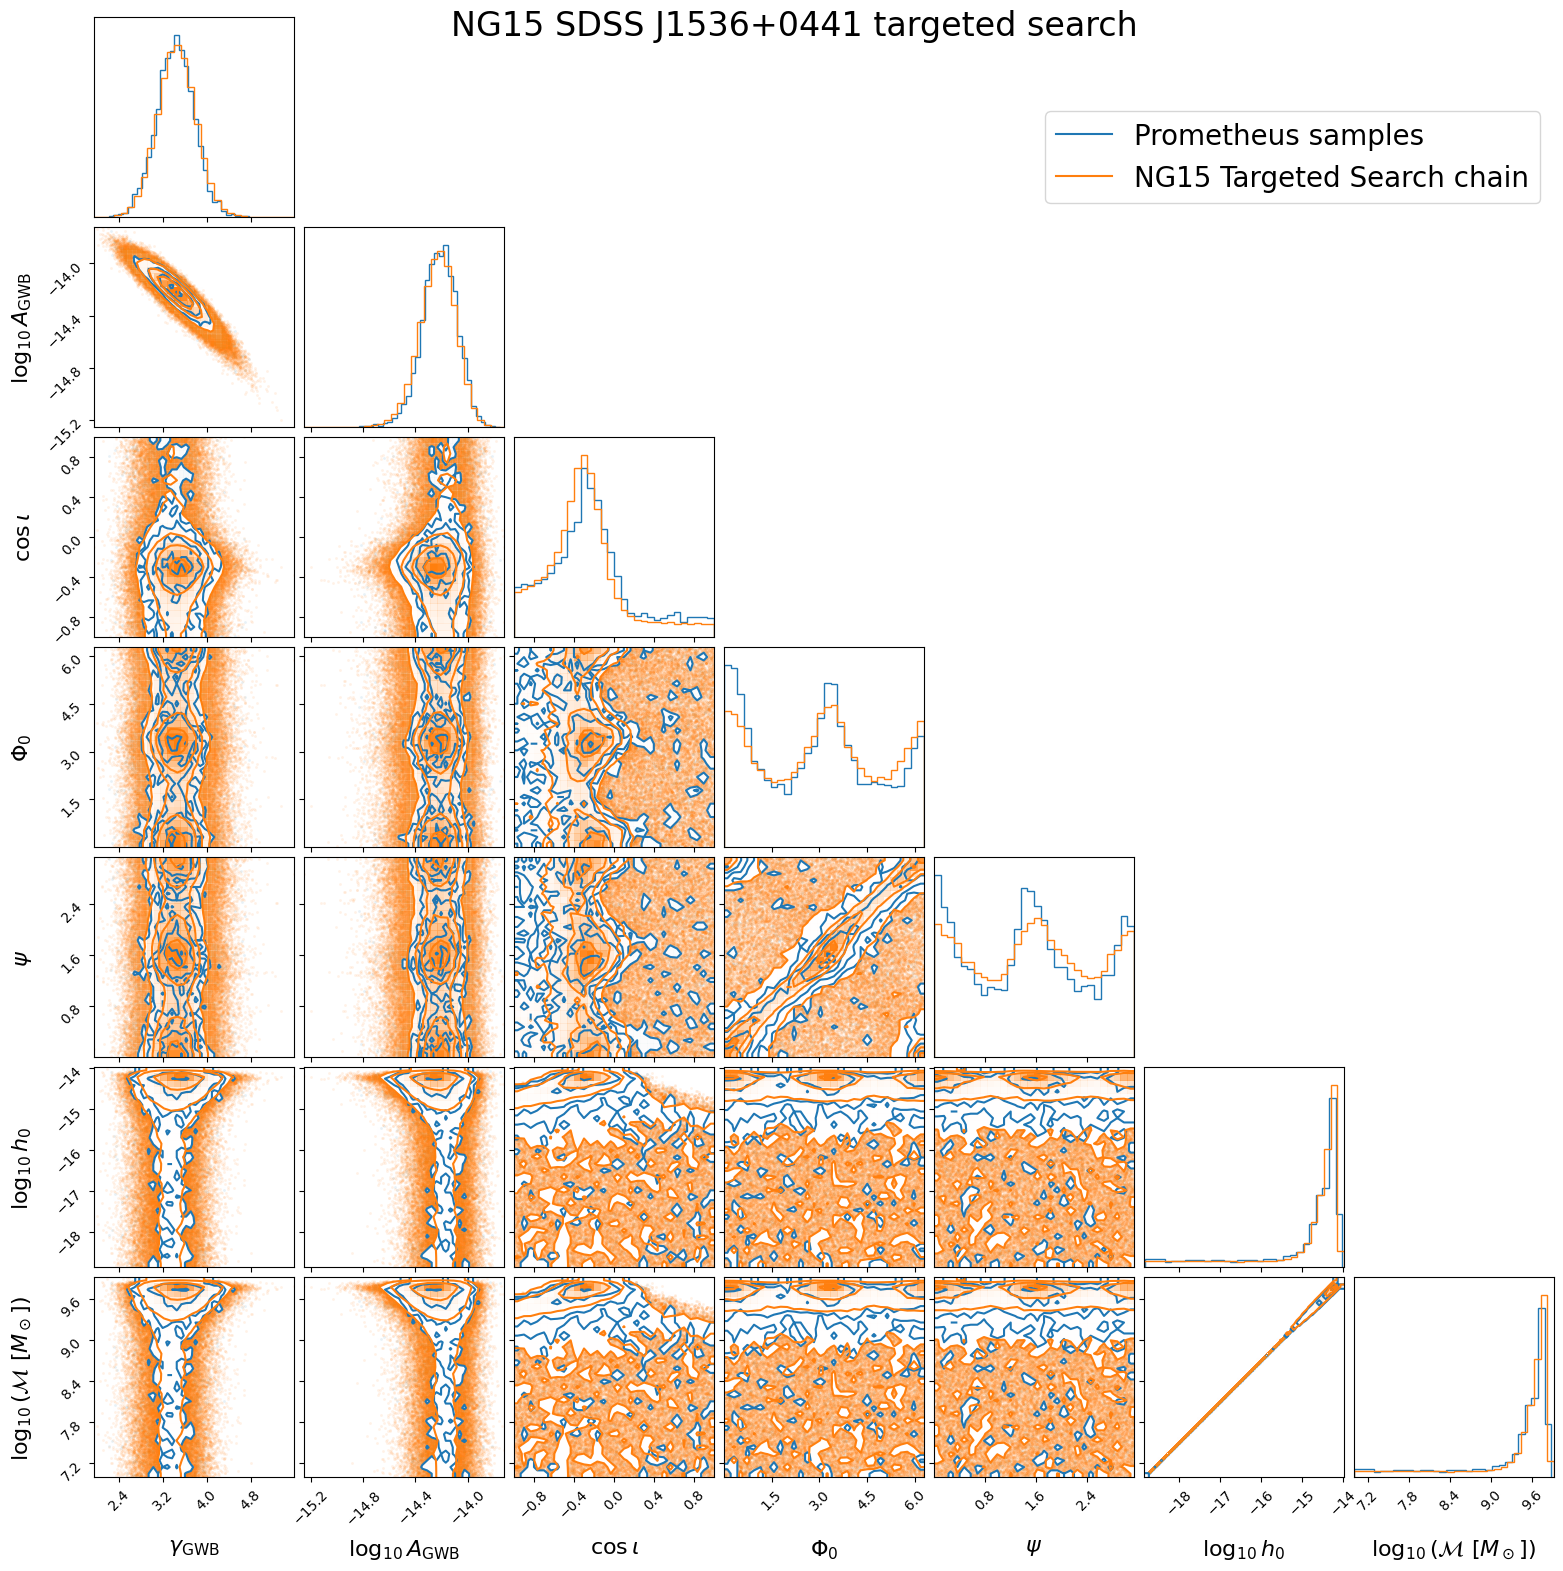

In [ ]:
# plot targeted search parameter estimation

# ordering we use for our model
cw_source_labels = np.array([r'$\log_{10}(\mathcal{M}\,\,[M_\odot])$',
                             r'$\cos{\iota}$', r'$\psi$', r'$\Phi_0$',
                             r'$\log_{10}h_0$'])

# labels and re-ordering to match plot
reordering = np.array([1, -2, 2, -1, 0])
gwb_labels = np.array([r'$\gamma_\text{GWB}$',
                       r'$\log_{10}A_\text{GWB}$'])
labels = np.concatenate((gwb_labels, cw_source_labels[reordering]))

# CW samples from Prometheus
cw_samples = np.array(samples['cw_evolve'])
# add deterministic log10(h) samples to match plot from paper
log10_h = (jnp.log10(2) + 5/3*cw_samples[:, 0] + 5/3*jnp.log10(utils.Tsun)
               + jnp.log10(jnp.pi) + 2/3*log10_fgw_fixed
               -jnp.log10(dist_Mpc_fixed) -jnp.log10(utils.Mpc) + jnp.log10(utils.c))
cw_samples = np.concatenate((cw_samples, log10_h[:, None]), axis=1)[:, reordering]

# add GWB samples
gwb_samples = np.array(samples['gwb_pl'])[:, ::-1]
gwb_cw_samples = np.concatenate((gwb_samples, cw_samples), axis=1)

# make corner plot
fig = corner.corner(gwb_cw_samples,
                    bins=30,
                    labels=labels,
                    label_kwargs={'fontsize':16},
                    color='C0',
                    hist_kwargs={'density': True})

# add samples from targeted search
targeted_gwb_cw_samples = np.concatenate((targeted_gwb_samples,
                                          targeted_cw_samples[:, reordering]),
                                          axis=1)
corner.corner(data=targeted_gwb_cw_samples,
              bins=30,
              fig=fig,
              color='C1',
              hist_kwargs={'density': True})

# plot legend/title
axes = np.array(fig.axes).reshape((len(reordering) + 2, len(reordering) + 2))
axes[0, -1].plot([], [], color='C0', label='Prometheus samples')
axes[0, -1].plot([], [], color='C1', label='NG15 Targeted Search chain')
axes[0, -1].legend(fontsize=20, loc='lower right')
fig.suptitle('NG15 SDSS J1536+0441 targeted search',
             fontsize=24)
fig.show()